MAE measures the average magnitude of errors between predicted and actual values, without considering their direction.
- 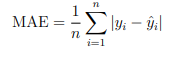

In [1]:
from sklearn.metrics import mean_absolute_error

# True and predicted values
y_true = [3.0, -0.5, 2.0, 7.0]
y_pred = [2.5, 0.0, 2.1, 7.8]

# Compute MAE
mae = mean_absolute_error(y_true, y_pred)
print(f"MAE: {mae:.2f}")

MAE: 0.47


# Weighted Least Squares (WLS)
Weighted Least Squares (WLS) — a powerful twist on ordinary least squares (OLS) when heteroscedasticity (unequal variance in errors) kicks in.

In [2]:
import statsmodels.api as sm
import numpy as np

# Simulated data
X = np.arange(10)
y = 2 * X + np.random.normal(scale=0.5 + X * 0.3)  # increasing noise
weights = 1 / (0.5 + X * 0.3)**2  # inverse variance = weight

# Add constant for intercept
X = sm.add_constant(X)

# WLS regression
model = sm.WLS(y, X, weights=weights)
results = model.fit()
print(results.summary())

                            WLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.956
Model:                            WLS   Adj. R-squared:                  0.951
Method:                 Least Squares   F-statistic:                     175.2
Date:                Sat, 26 Apr 2025   Prob (F-statistic):           1.01e-06
Time:                        06:53:22   Log-Likelihood:                -16.926
No. Observations:                  10   AIC:                             37.85
Df Residuals:                       8   BIC:                             38.46
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.2286      0.390     -0.587      0.5

C:\Users\delll\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:531: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=10
  res = hypotest_fun_out(*samples, **kwds)


# Polynomial Regression Hypothesis
Polynomial regression models the relationship between x and y as a
polynomial. It generalizes linear regression to non-linear patterns
- 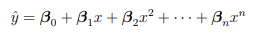.

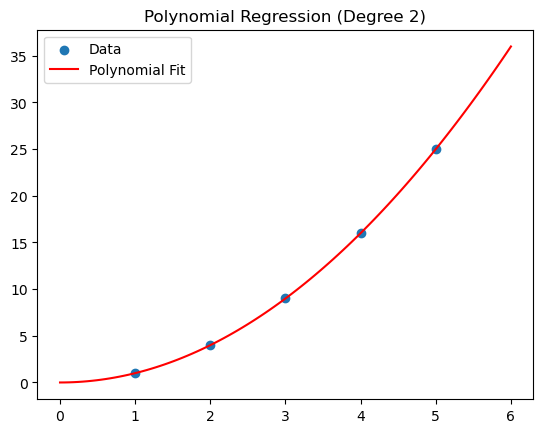

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

# Sample data
X = np.array([1, 2, 3, 4, 5]).reshape(-1, 1)
y = np.array([1, 4, 9, 16, 25])  # Quadratic relationship

# Transform to polynomial features (degree=2)
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)

# Fit the model
model = LinearRegression()
model.fit(X_poly, y)

# Predict
X_test = np.linspace(0, 6, 100).reshape(-1, 1)
X_test_poly = poly.transform(X_test)
y_pred = model.predict(X_test_poly)

# Plot
plt.scatter(X, y, label="Data")
plt.plot(X_test, y_pred, color='red', label="Polynomial Fit")
plt.title("Polynomial Regression (Degree 2)")
plt.legend()
plt.show()